# **Twitter Sentiment Classification with Bert**

### Install transformers

In [ ]:
!pip install transformers

### Import needed library dependencies

In [ ]:
import pandas as pd
import numpy as np
import nltk

from string import digits
import re
import string

from sklearn import preprocessing
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from torchtext.legacy.data import Dataset
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import BertTokenizer, BertModel

### Mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Mount GPU resources (if available)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')
torch.cuda.empty_cache()

Using cuda device


### Reading training dataset

In [ ]:
df_train = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_train.csv", index_col=[0])
df_train.head()

,tweet,label
0,Sip N Shop Come thru right now #Marjais #Popul...,0
1,I don't know about you but My family and I wil...,1
2,@MSignorile Immunizations should be mandatory....,2
3,President Obama spoke in favor of vaccination ...,0
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0


### Reading evaluation dataset

In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_dev.csv", index_col=[0])
df_test.head()

,tweet,label
0,@user They had a massive surge in with covid d...,1
1,Required vaccines for school: Parents and guar...,0
2,“@KCStar: Two more Johnson County children hav...,0
3,NV can do better. Which states are the best (a...,2
4,Nothing like killing ourselves w/ our own fear...,2


###Text Data Cleaning

>For the data cleaning process, the following were included: 
* Remove all whitespaces and newlines 
* Remove all special characters and punctuation
* Replace contractions with full words (despite that they might be removed   later from the stopwords)
* Splitted attached words e.g.  “ForTheWin” =>  “For The Win”
* Lowered all capital letters  
* Removed Numbers from text corpus
* Standarizing sentences

>Both train and test data are preprocessed in the same exact way.

>(reference link: [python-efficient-text-data-cleaning](https://www.geeksforgeeks.org/python-efficient-text-data-cleaning/)

In [ ]:
def numbers(x):
  return re.sub(r'[0-9]+', '', x)

def blank_space(x):
  return re.sub('[^A-Za-z0-9]+', ' ', x)

def standarize_sentence(x):
  return ''.join(''.join(word)[:2] for word in x) 

def apostrophe_words(x):
  Apos_dict={"'s":" is","'t":" not","'m":" am","'ll":" will", "'d":" would","'ve":" have","'re":" are", 
             "’s":" is","’t":" not","’m":" am", "’d":" would","’ve":" have","’re":" are", "’ll": "will"} 
  for key,value in Apos_dict.items(): 
    if key in x:
      x =  x.replace(key,value)
      return x
  return x

def split_words(x):
  return " ".join([word for word in re.split("([A-Z][a-z]+[^A-Z]*)",x) if word])

def shallow_cleaning(df):
  remove_digits = str.maketrans('', '', digits)
  df['tweet'] = df['tweet'].apply(lambda x: blank_space(x))
  df['tweet'] = df['tweet'].apply(lambda x: apostrophe_words(x))
  df['tweet'] = df['tweet'].str.strip()
  df['tweet'] = df['tweet'].str.lower()
  df['tweet'] = df['tweet'].apply(lambda x: numbers(x))
  df['tweet'] = df['tweet'].apply(lambda x: split_words(x))
  df['tweet'] = df['tweet'].apply(lambda x: standarize_sentence(x))
  return df

df_train = shallow_cleaning(df_train)
display(df_train)

,tweet,label
0,sip n shop come thru right now marjais popular...,0
1,i don t know about you but my family and i wil...,1
2,msignorile immunizations should be mandatory p...,2
3,president obama spoke in favor of vaccination ...,0
4,myfoxla arizona monitoring hundreds for measle...,0
...,...,...
15971,salon if u believe the anti vax nutcases cause...,1
15972,how do you feel about parents who don t vaccin...,0
15973,preschoolers tested for measles in simi valle...,0
15974,finance minister budget offers room to procure...,0


In [ ]:
df_test = shallow_cleaning(df_test)
display(df_test)

,tweet,label
0,user they had a massive surge in with covid de...,1
1,required vaccines for school parents and guard...,0
2,kcstar two more johnson county children have m...,0
3,nv can do better which states are the best and...,2
4,nothing like killing ourselves w our own fear ...,2
...,...,...
2277,rt abc number of measles cases reported in cal...,0
2278,evidence points to the idea that measles affec...,0
2279,where s savedyouaclick voxdotcom why you shoul...,2
2280,some of my favorite people have autism if that...,2


### **Initialize Tokenizer**

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer

PreTrainedTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_len=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'})

### **Custom Dataset**

Create custom dataset class for the train and evaluation dataset. It also passes the data from the bert tokenizer.

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, data, tokenizer=None, device='cpu'):
    self.device = device
    self.labels = data['label']
    self.data = data['tweet']
    self.tokenizer = tokenizer

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    x = self.tokenizer(self.data[idx], padding='max_length', max_length=64, truncation=True, return_tensors='pt')
    y = self.labels[idx]
    return x, y

In [ ]:
train_dataset = CustomDataset(df_train, tokenizer, device)
test_dataset = CustomDataset(df_test, tokenizer, device)

### **Load data and create batches**

We create batches of size 64. We ended up with this number after experiments run. If more records are added in the batch, colab runs out of memory during the model's trainning.

In [ ]:
pin_memory = False
if(device == 'cuda'):
  pin_memory = True

print(pin_memory)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=pin_memory)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, pin_memory=pin_memory)

True


### Define Neural Network class

**Architecture:**


*   Pretrained Bert model ("bert-based-uncased") with output 768.
*   Dropout layer with probability p=0.3 (this value is set after experiments) which is fed the data from Bert layer's output.
*   First linear layer fed with bert's output.
*   ReLu activation Function
*   Final Linear layer with input_size the size of the previous linear layer and output 3 (the number of the classes of the classification problem at hand).



In [ ]:
class Model(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_size = input_size
        self.bert_input = 768
        self.output_size = output_size

        self.Bert = BertModel.from_pretrained("bert-base-uncased")
        self.Linear1 = nn.Linear(self.bert_input, self.input_size) 
        self.dropout = nn.Dropout(0.30)
        self.relu = nn.ReLU()
        self.Linear = nn.Linear(self.input_size, self.output_size)        
        
    def forward(self, x, mask):
        _, bertOutput = self.Bert(x, attention_mask=mask, return_dict=False)
        dropout = self.dropout(bertOutput)
        linear1 = self.Linear1(dropout)
        relu = self.relu(linear1)
        output = self.Linear(relu)         
        return output

### Define model parameters
Here, we define the number of epochs for the model's training process. We also load the model of our choice, the optimizer and the scheduler.

The learning rate is set to 1e-5.

In [ ]:
N_EPOCHS = 10
input_size = 64
output_size = 3

net = Model(input_size=input_size, output_size=output_size)

for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

LR = 1e-5
optimizer = torch.optim.Adam(net.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', patience=4, factor=0.5, cooldown=1)

if device == 'cuda':
  net.to(device)
  criterion.to(device)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Bert.embeddings.word_embeddings.weight torch.Size([30522, 768])
Bert.embeddings.position_embeddings.weight torch.Size([512, 768])
Bert.embeddings.token_type_embeddings.weight torch.Size([2, 768])
Bert.embeddings.LayerNorm.weight torch.Size([768])
Bert.embeddings.LayerNorm.bias torch.Size([768])
Bert.encoder.layer.0.attention.self.query.weight torch.Size([768, 768])
Bert.encoder.layer.0.attention.self.query.bias torch.Size([768])
Bert.encoder.layer.0.attention.self.key.weight torch.Size([768, 768])
Bert.encoder.layer.0.attention.self.key.bias torch.Size([768])
Bert.encoder.layer.0.attention.self.value.weight torch.Size([768, 768])
Bert.encoder.layer.0.attention.self.value.bias torch.Size([768])
Bert.encoder.layer.0.attention.output.dense.weight torch.Size([768, 768])
Bert.encoder.layer.0.attention.output.dense.bias torch.Size([768])
Bert.encoder.layer.0.attention.output.LayerNorm.weight torch.Size([768])
Bert.encoder.layer.0.attention.output.LayerNorm.bias torch.Size([768])
Bert.encoder

In [ ]:
net

Model(
  (Bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      

In [ ]:
def getMax(array, size):
  max = -1
  counter = 0
  for element in array:
    if max < element:
      max = element
      label = counter
    counter+=1
  return label

def getPrediction(y_pred, out_dim=1):
  res_list = []
  for line in y_pred:
    res_list.append(getMax(line, 3))
  res_df = pd.DataFrame(data=res_list, columns=['Predicted Labels'])
  if device == 'cuda':
    return torch.tensor(res_df.values, dtype=torch.long).to('cuda')
  else:
    return torch.tensor(res_df.values, dtype=torch.long)

### Train Network

Epochs: 10 (after the conduction of multiple experiments)

The model is trained with the entire train dataset and then tested (as a mockup) with the same dataset.

In [ ]:
train_loss = []
val_loss = []
y_test = []
prediction = []

train_stats = {'train_loss': [], 'val_loss': []}


for epoch in range(N_EPOCHS):
  batch_losses = []
  y_test = []
  prediction = []
  running_loss = 0.0
  i=0

  # Ensure net in training mode
  net.train()
  for batch, label in train_dataloader:
    # Zero out gradients
    optimizer.zero_grad()
    
    mask = batch['attention_mask'].to(device)
    x = batch['input_ids'].squeeze(1).to(device)
    output = net(x, mask)
    loss = criterion(output, label.to(device))
    
    loss.backward() 
    optimizer.step()
       
    # Track loss
    # CE loss
    batch_losses.append(loss.item())
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)     

  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")

  train_stats['train_loss'].append(float(running_loss))
  
  # Compute the validation score
  net.eval()
  running_loss_val = 0.0

  for batch, label in test_dataloader:
    
    mask = batch['attention_mask'].to(device)
    x = batch['input_ids'].squeeze(1).to(device)
    y_pred = net(x, mask)
    y_pred_label = getPrediction(y_pred, 3)
    
    loss = criterion(y_pred, label.to(device))
    
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)
    
    prediction.append(y_pred_label.flatten().tolist())
    y_test.append(label.cpu().tolist())
    i += 1

  train_stats['val_loss'].append(running_loss)
  scheduler.step(train_stats['val_loss'][-1])

prediction = sum(prediction, [])
y_test = sum(y_test, [])

Epoch   0: Loss = 0.46829700469970703
Epoch   1: Loss = 0.6625483632087708
Epoch   2: Loss = 0.5046399831771851
Epoch   3: Loss = 0.41617637872695923
Epoch   4: Loss = 0.21491992473602295
Epoch   5: Loss = 0.061628907918930054
Epoch   6: Loss = 0.4199770390987396
Epoch   7: Loss = 0.1685984581708908
Epoch   8: Loss = 0.07123404741287231
Epoch   9: Loss = 0.09636834263801575


### Train Classification Report

In [ ]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1065
           1       0.64      0.53      0.58       296
           2       0.71      0.81      0.76       921

    accuracy                           0.76      2282
   macro avg       0.73      0.70      0.71      2282
weighted avg       0.76      0.76      0.75      2282



Train Statistics Report


*   Train Loss: Model loss monitored during training phase
*   Val_Loss: Model loss monitored during evaluation phase

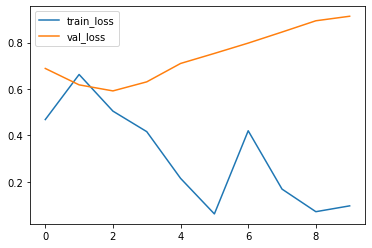

In [ ]:
train_stats_df = pd.DataFrame(train_stats)
train_stats_df.plot()

### **Prediction**

In [ ]:
prediction = []
y_actual = []
y_test = []
batch_num = 0.0

net.eval()
accuracy = 0.0
f1 = 0.0
recall = 0.0
precision = 0.0
metrics = {'accuracy':0.0,
           'f1':0.0,
           'recall':0.0,
           'precision':0.0}

for batch, label in test_dataloader:  
  batch_num += 1
  batch_prediction = []
  y_batch = []

  mask = batch['attention_mask'].to(device)
  x = batch['input_ids'].squeeze(1).to(device)
  test_pred = net(x, mask)
  test_label_pred = getPrediction(test_pred, 3)

  test_pred = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_actual = np.array(label.cpu().flatten().detach().tolist())

  batch_prediction = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_batch = np.array(label.cpu().flatten().detach().tolist())

  prediction.append(test_label_pred.tolist())
  y_test.append(label.cpu().flatten().detach().tolist())

  #Compute the scores.
  accuracy += accuracy_score(y_batch, batch_prediction)
  f1 += f1_score(y_batch, batch_prediction, average='micro')
  recall += recall_score(y_batch, batch_prediction, average='micro')
  precision += precision_score(y_batch, batch_prediction, average='micro')

prediction = sum(prediction, [])
y_test = sum(y_test, [])


metrics['accuracy'] = accuracy/batch_num
metrics['f1'] = f1/batch_num
metrics['recall'] = recall/batch_num
metrics['precision'] = precision/batch_num

### **Test Classification Report**
In the report below we can see how the model fares with its predictions. 

In contrast to the models used in the previous homeworks, this one apperas to have a far better behavior with its training even taking less time and epochs in general.

For instance, we still see that the amount of data concentrating under each class has some impact on the prediction's accuracy, but still, this model's prediction seems far more accurate with less false-positive rates.

The model's precision for all classes is above 0.64 with class zero reaching as high as 0.84. Recall and f1-score are high as well. The lower one is class one which also has the smaller support.

The overall accuracy of the model is 0.76.



In [ ]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1065
           1       0.64      0.53      0.58       296
           2       0.71      0.81      0.76       921

    accuracy                           0.76      2282
   macro avg       0.73      0.70      0.71      2282
weighted avg       0.76      0.76      0.75      2282

